# Equilibrium OW spectral densities on square systems

Square systems $N_x=N_y=L=20,40,60,80$, hard walls at $x=L/4$ and $3L/4$ (inclusive topological slab), $\alpha_1=1$, $\alpha_2=30$, overcomplete Wannier (OW) range $n_{\mathrm{shell}}=1$, and zero boundary twists. One deterministic half-filled ground state per size.

## CPU allocation
Edit the inclusive CPU range below (eight CPUs by default). Canonical CPU OW construction and equilibrium linear algebra only; no circuit simulation. Sizes run sequentially to bound memory.

In [1]:
import os
# Preserve the original kernel affinity so this cell can be rerun with a new range.
if "AVAILABLE_CPUS" not in globals():
    AVAILABLE_CPUS = sorted(os.sched_getaffinity(0))
CPU_RANGE = (AVAILABLE_CPUS[0], AVAILABLE_CPUS[min(7, len(AVAILABLE_CPUS)-1)])
selected_cpus = list(range(CPU_RANGE[0], CPU_RANGE[1] + 1))
if not selected_cpus or not set(selected_cpus).issubset(AVAILABLE_CPUS):
    raise ValueError("CPU_RANGE must be an inclusive range of available CPUs")
os.sched_setaffinity(0, selected_cpus)
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[variable] = str(len(selected_cpus))
from threadpoolctl import threadpool_limits
blas_limit = threadpool_limits(limits=len(selected_cpus))
print("Allocated CPUs:", selected_cpus)

Allocated CPUs: [0, 1, 2, 3, 4, 5, 6, 7]


## Two different spectra

The repository's OW parent is
$$H_{\mathrm{flat}}=\sum_{\boldsymbol R}(P_{A+}+P_{B+}-P_{A-}-P_{B-}),\quad P=|W\rangle\langle W|.$$
The normalized OW modes are nonorthogonal, so this signed sum does **not** have only $\pm1$ energies. Its energy density includes every level, with no energy rescaling and no endpoint exclusion:
$$\rho_H(E)=\frac{1}{2N_xN_y}\sum_j\delta(E-E_j).$$

At half filling, occupy the lowest $N_xN_y$ eigenstates of this parent. Resolve the calculation in conserved $y$ momentum using the existing equilibrium-reference algorithm; fill globally across momentum blocks with a stable energy sort. The saved half-filling gap diagnoses possible degeneracy.

For the subsystem containing all $x$, $y=0,\ldots,N_y/2-1$, and both orbitals, compute the restricted occupation projector $C_A$ and centered covariance $G_A=2C_A-I$. Here $G$ follows the engine's centered convention, whereas the paper uses $G$ for an uncentered correlation matrix. Diagonalize first, then retain $|\lambda|<1-10^{-8}$ for the mixed-mode plot.

Both histograms are separately normalized to unit area per size and use log vertical axes. Empty bins are omitted on log axes without pseudocounts. Each equilibrium spectrum is discrete; unlike the circuit comparison, no 100-trajectory pooling smooths these curves.

The square-system half-subsystem contains all $x$, $y=0,\ldots,L/2-1$, and both orbitals: $L^2$ modes. Both cut length and volume grow with $L$. The hard-wall parent has disconnected topological and trivial sectors; concatenate their restricted spectra only after verifying the cross-sector covariance vanishes.

If the gap at half filling falls below $10^{-10}$, the pure ground state depends on the choice in the numerically unresolved Fermi subspace. Preserve the reference's stable global energy sorting across momentum blocks and record the gap. Do not silently average ground states or introduce a twist.

## Configuration and source identity

In [2]:
from pathlib import Path
from typing import Any
from datetime import datetime,timezone
import sys,importlib,hashlib,json,time,contextlib,io
import numpy as np
import scipy
from scipy.linalg import eigh,eigvalsh
from tqdm.auto import tqdm
from IPython.display import display,Markdown,Image
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/"PROJECT_ADMIN/REPO_POLICY.md").is_file())
BUNDLE=ROOT/"00_WORKSPACE/CURRENT/final_production_new_designs/06_domain_wall_flattened_ground_state_reference"
OUTPUT_DIR=BUNDLE/"analysis_outputs/equilibrium_flattened_spectral_densities_square_L20_40_60_80_v1"
SOURCE_DIR=ROOT/"src/fgtn"
sys.path.insert(0,str(SOURCE_DIR))
engine_module=importlib.import_module("classA_U1FGTN")
assert Path(engine_module.__file__).resolve()==(SOURCE_DIR/"classA_U1FGTN.py").resolve()
classA_U1FGTN=engine_module.classA_U1FGTN
SIZES=[20,40,60,80]
TRANSLATION_TOLERANCE=2e-10
BOUND_TOL=1e-8
FORCE_RECOMPUTE=False
def require(ok,message):
    if not ok: raise ValueError(message)
def sha256(p):
    with Path(p).open("rb") as f: return hashlib.file_digest(f,"sha256").hexdigest()
def native(value):
    if isinstance(value,np.ndarray): return value.tolist()
    if isinstance(value,np.generic): return value.item()
    raise TypeError(type(value).__name__)
source_paths=[SOURCE_DIR/"classA_U1FGTN.py",SOURCE_DIR/"occupied_frame.py",
              BUNDLE/"run_flattened_ground_state_large_ny.py"]
source_hashes={str(p.relative_to(ROOT)):sha256(p) for p in source_paths}
contract={"schema":"equilibrium_flattened_square_density_v1","sizes":SIZES,
          "geometry":"Nx=Ny=L","DW":True,"dw_truncation":True,
          "wall_rule":"[L//4,3*L//4] inclusive topological slab","nshell":1,
          "alpha_1":1,"alpha_2":30,"trial_orbitals":"X","twist_x":0,"twist_y":0,
          "filling":0.5,"subsystem":"all x, y=0..L/2-1, both orbitals",
          "occupation":"lowest half globally; stable sort across y momentum blocks",
          "restricted_solver":"independent hard-wall sectors; cross-block validation",
          "source_hashes":source_hashes}
identity=hashlib.sha256(json.dumps(contract,sort_keys=True).encode()).hexdigest()
print(json.dumps(contract,indent=2))
print("Canonical CPU source:",engine_module.__file__)

{
  "schema": "equilibrium_flattened_square_density_v1",
  "sizes": [
    20,
    40,
    60,
    80
  ],
  "geometry": "Nx=Ny=L",
  "DW": true,
  "dw_truncation": true,
  "wall_rule": "[L//4,3*L//4] inclusive topological slab",
  "nshell": 1,
  "alpha_1": 1,
  "alpha_2": 30,
  "trial_orbitals": "X",
  "twist_x": 0,
  "twist_y": 0,
  "filling": 0.5,
  "subsystem": "all x, y=0..L/2-1, both orbitals",
  "occupation": "lowest half globally; stable sort across y momentum blocks",
  "restricted_solver": "independent hard-wall sectors; cross-block validation",
  "source_hashes": {
    "src/fgtn/classA_U1FGTN.py": "6b73d083c2006fbe0b7cf36bec0b00f5577da0f419388f96e0fbf6ca152e72af",
    "src/fgtn/occupied_frame.py": "5e689503de89812546c98d4e474511ded13b8ac2b42d57b41c730ed444e2d4c1",
    "00_WORKSPACE/CURRENT/final_production_new_designs/06_domain_wall_flattened_ground_state_reference/run_flattened_ground_state_large_ny.py": "5bd31618d11be749e6c4d0393cc1bae1c3bd89c979dd6b4387bd94c26a1c3682"
  }


## Equilibrium calculation

Use momentum blocks of size 2L and diagonalize independent hard-wall sectors of the half-subsystem. Check energies, trace, Hermiticity, full-state purity, and spectral bounds. At L=20 compare to the full real-space Hamiltonian and full reduced-matrix solves. Save each completed size immediately.

In [3]:
def flattened_momentum_projector(
    model: classA_U1FGTN,
):
    """Diagonalize the exact flattened parent in conserved y momentum."""

    ny = int(model.Ny)
    nx = int(model.Nx)
    q = 2 * nx
    h_k = np.zeros((ny, q, q), dtype=np.complex128)
    translation_covariance = 0.0
    phase = np.exp(
        -2j
        * np.pi
        * np.arange(ny, dtype=np.float64)[:, None]
        * np.arange(ny, dtype=np.float64)[None, :]
        / float(ny)
    )
    channels = (
        ("WF_Ap", 1.0),
        ("WF_Bp", 1.0),
        ("WF_Am", -1.0),
        ("WF_Bm", -1.0),
    )
    for name, sign in channels:
        frame = np.asarray(getattr(model, name), dtype=np.complex128)
        frame = frame.reshape(ny, q, nx, ny)
        frame_k = np.fft.fft(frame, axis=0) / np.sqrt(float(ny))
        expected = frame_k[:, :, :, :1] * phase[:, None, None, :]
        translation_covariance = max(
            translation_covariance, float(np.max(np.abs(frame_k - expected)))
        )
        representative = frame_k[:, :, :, 0]
        h_k += sign * float(ny) * np.einsum(
            "kar,kbr->kab",
            representative,
            representative.conj(),
            optimize=True,
        )
    h_hermiticity = float(
        np.max(np.abs(h_k - h_k.conj().transpose(0, 2, 1)))
    )
    h_k = 0.5 * (h_k + h_k.conj().transpose(0, 2, 1))

    energies = np.empty((ny, q), dtype=np.float64)
    eigenvectors = np.empty((ny, q, q), dtype=np.complex128)
    for momentum in range(ny):
        energies[momentum], eigenvectors[momentum] = eigh(
            h_k[momentum], check_finite=False, driver="evd"
        )
    total_rank = ny * q // 2
    order = np.argsort(energies.ravel(), kind="stable")
    occupied = np.zeros(ny * q, dtype=bool)
    occupied[order[:total_rank]] = True
    occupied = occupied.reshape(ny, q)
    projector_k = np.empty_like(h_k)
    for momentum in range(ny):
        vectors = eigenvectors[momentum][:, occupied[momentum]]
        projector_k[momentum] = vectors @ vectors.conj().T
    projector_delta = np.fft.ifft(projector_k, axis=0)

    diagnostics = {
        "half_filling_rank": total_rank,
        "negative_energy_count": int(np.count_nonzero(energies < 0.0)),
        "half_filling_gap": float(
            energies.ravel()[order[total_rank]]
            - energies.ravel()[order[total_rank - 1]]
        ),
        "minimum_absolute_energy": float(np.min(np.abs(energies))),
        "occupied_rank_by_ky": occupied.sum(axis=1).astype(np.int64),
        "ow_y_translation_covariance_max_abs": translation_covariance,
        "hamiltonian_block_hermiticity_max_abs": h_hermiticity,
        "projector_block_hermiticity_max_abs": float(
            np.max(
                [
                    np.max(
                        np.abs(
                            projector_delta[delta]
                            - projector_delta[-delta % ny].conj().T
                        )
                    )
                    for delta in range(ny)
                ]
            )
        ),
        "projector_idempotency_max_abs": float(
            np.max(
                [
                    np.max(np.abs(block @ block - block))
                    for block in projector_k
                ]
            )
        ),
        "projector_rank_residual": abs(
            float(np.trace(projector_k, axis1=1, axis2=2).real.sum())
            - float(total_rank)
        ),
    }
    if translation_covariance > TRANSLATION_TOLERANCE:
        raise FloatingPointError(
            "OW modes violate y-translation covariance: "
            f"{translation_covariance:.6e}"
        )
    return projector_delta, diagnostics, energies

def restricted_projector(projector_delta: np.ndarray, rows: Any) -> np.ndarray:
    rows = np.asarray(tuple(rows), dtype=np.int64)
    ny, q = projector_delta.shape[:2]
    if rows.size == 0 or np.any(rows < 0) or np.any(rows >= ny):
        raise ValueError("restricted rows must be nonempty representatives in [0,Ny)")
    if np.unique(rows).size != rows.size:
        raise ValueError("restricted rows must be distinct")
    delta = (rows[:, None] - rows[None, :]) % ny
    return (
        projector_delta[delta]
        .transpose(0, 2, 1, 3)
        .reshape(rows.size * q, rows.size * q)
        .copy()
    )

In [4]:

spectra_by_size,energies_by_size,diagnostics_by_size={},{},{}
for L in tqdm(SIZES,desc="Square equilibrium spectra",unit="size"):
    cache=OUTPUT_DIR/f"equilibrium_spectra_L{L:03d}.npz"
    receipt=OUTPUT_DIR/f"equilibrium_spectra_L{L:03d}.json"
    reuse=False
    if cache.exists() and receipt.exists() and not FORCE_RECOMPUTE:
        old=json.loads(receipt.read_text())
        reuse=old.get("identity")==identity and old.get("cache_sha256")==sha256(cache)
    if reuse:
        with np.load(cache,allow_pickle=False) as z:
            require(int(z["L"])==L and z["identity"].item()==identity,"Cached identity mismatch")
            spectrum,energies=z["centered_eigenvalues"],z["energies"]
        diag=old["diagnostics"]
        print(f"L={L}: loaded verified cache.",flush=True)
    else:
        started=time.perf_counter()
        print(f"L={L}: constructing canonical OW modes; half-system dimension {L*L}.",flush=True)
        with contextlib.redirect_stdout(io.StringIO()):
            model=classA_U1FGTN(Nx=L,Ny=L,DW=True,nshell=1,filling_frac=.5,
                                alpha_1=1,alpha_2=30,trial_orbitals="X",dw_truncation=True)
            model.construct_OW_projectors(nshell=1,DW=True,trial_orbitals="X",dw_truncation=True)
        walls=[L//4,3*L//4]
        require(list(model.DW_loc)==walls,"Unexpected wall geometry")
        del model.Pplus,model.Pminus
        print(f"L={L}: diagonalizing {L} momentum blocks of size {2*L}.",flush=True)
        delta,diag,energy_blocks=flattened_momentum_projector(model)
        energies=np.sort(energy_blocks.ravel())
        require(np.isfinite(energies).all(),"Nonfinite parent energies")
        for key in ["hamiltonian_block_hermiticity_max_abs","projector_block_hermiticity_max_abs",
                    "projector_idempotency_max_abs","projector_rank_residual"]:
            require(diag[key]<1e-9,f"Equilibrium check failed: {key}")
        if L==20:
            H=np.zeros((2*L*L,2*L*L),dtype=np.complex128)
            for name,sign in [("WF_Ap",1),("WF_Bp",1),("WF_Am",-1),("WF_Bm",-1)]:
                W=np.asarray(getattr(model,name)).reshape(2*L*L,-1)
                H+=sign*(W@W.conj().T)
            require(np.max(np.abs(H-H.conj().T))<1e-12,"Dense parent not Hermitian")
            ed,U=eigh((H+H.conj().T)/2,driver="evd")
            diag["dense_energy_crosscheck_max_error"]=float(np.max(np.abs(ed-energies)))
            require(diag["dense_energy_crosscheck_max_error"]<1e-10,"Dense/block energy mismatch")
            Pfull=restricted_projector(delta,range(L))
            diag["ground_state_commutator_max_error"]=float(np.max(np.abs(H@Pfull-Pfull@H)))
            diag["ground_state_energy_trace_error"]=float(abs(np.trace(H@Pfull).real-ed[:L*L].sum()))
            require(diag["ground_state_commutator_max_error"]<1e-9,"Ground-state commutator mismatch")
            require(diag["ground_state_energy_trace_error"]<1e-8,"Ground-state energy mismatch")
            del H,U,Pfull,W
        del model
        C=restricted_projector(delta,range(L//2))
        require(C.shape==(L*L,L*L) and np.isfinite(C).all(),"Invalid restricted projector")
        diag["restricted_hermiticity_max_error"]=float(np.max(np.abs(C-C.conj().T)))
        require(diag["restricted_hermiticity_max_error"]<1e-12,"Restricted matrix not Hermitian")
        x=(np.arange(L*L)//2)%L
        topo=(x>=walls[0])&(x<=walls[1])
        sectors=[np.flatnonzero(topo),np.flatnonzero(~topo)]
        diag["restricted_sector_dimensions"]=[len(i) for i in sectors]
        cross=float(np.max(np.abs(C[np.ix_(*sectors)])))
        diag["restricted_cross_sector_max_error"]=cross
        require(cross<1e-12,"Hard-wall sectors are not decoupled")
        values_by_sector=[]
        crosscheck=0.0
        for sector,i in enumerate(tqdm(sectors,desc=f"L={L}: reduced sectors",unit="sector",leave=False)):
            Cs=C[np.ix_(i,i)]
            Gs=2*Cs-np.eye(len(i))
            print(f"L={L}: reduced sector {sector+1}, dimension {len(i)}.",flush=True)
            vals=eigvalsh((Gs+Gs.conj().T)/2,driver="evr")
            require(np.isfinite(vals).all(),"Nonfinite reduced eigenvalues")
            values_by_sector.append(vals)
            if L==20:
                alternate=2*eigvalsh((Cs+Cs.conj().T)/2,driver="evd")-1
                crosscheck=max(crosscheck,float(np.max(np.abs(vals-alternate))))
            del Cs,Gs
        spectrum=np.sort(np.concatenate(values_by_sector))
        if L==20:
            direct=eigvalsh(C+C.conj().T-np.eye(L*L),driver="evd")
            diag["full_vs_sector_restricted_spectrum_error"]=float(np.max(np.abs(spectrum-direct)))
            require(diag["full_vs_sector_restricted_spectrum_error"]<1e-10,"Sector solver mismatch")
            diag["occupation_crosscheck_max_error"]=crosscheck
            require(crosscheck<1e-10,"Occupation crosscheck failed")
        require(spectrum.min()>=-1-BOUND_TOL and spectrum.max()<=1+BOUND_TOL,"Reduced spectrum bounds")
        diag["restricted_trace_error"]=float(abs(spectrum.sum()-(2*np.trace(C)-L*L)))
        require(diag["restricted_trace_error"]<1e-8,"Restricted trace mismatch")
        diag.update({
            "raw_centered_minimum":float(spectrum.min()),"raw_centered_maximum":float(spectrum.max()),
            "energy_minimum":float(energies.min()),"energy_maximum":float(energies.max()),
            "half_filling_gap_resolved_at_1e-10":bool(diag["half_filling_gap"]>1e-10),
            "walls":walls,"elapsed_seconds":time.perf_counter()-started})
        if not diag["half_filling_gap_resolved_at_1e-10"]:
            print(f"L={L}: Fermi gap unresolved at 1e-10; using recorded stable-sort occupation.",flush=True)
        tmp=cache.with_suffix(".tmp.npz")
        np.savez_compressed(tmp,energies=energies,energy_by_ky=energy_blocks,
                            centered_eigenvalues=spectrum,L=L,identity=identity)
        tmp.replace(cache)
        receipt.write_text(json.dumps({"identity":identity,"contract":contract,"cache_sha256":sha256(cache),
                            "diagnostics":diag},default=native,indent=2,allow_nan=False)+"\n")
        del delta,C
    require(spectrum.shape==(L*L,) and energies.shape==(2*L*L,),"Cached shape mismatch")
    spectra_by_size[L],energies_by_size[L],diagnostics_by_size[L]=spectrum,energies,diag
    print(f"{L}x{L}: saved; energy range [{energies.min():.6f},{energies.max():.6f}]; "
          f"gap {diag['half_filling_gap']:.3e}; elapsed {diag['elapsed_seconds']:.1f} s.",flush=True)


Square equilibrium spectra:   0%|          | 0/4 [00:00<?, ?size/s]

L=20: loaded verified cache.


20x20: saved; energy range [-2.311040,2.311040]; gap 1.502e-09; elapsed 1.1 s.


L=40: loaded verified cache.


40x40: saved; energy range [-2.311040,2.311040]; gap 2.499e-15; elapsed 9.1 s.


L=60: loaded verified cache.


60x60: saved; energy range [-2.311040,2.311040]; gap 3.314e-17; elapsed 52.4 s.


L=80: loaded verified cache.


80x80: saved; energy range [-2.311040,2.311040]; gap 1.771e-15; elapsed 181.7 s.


## Hamiltonian energy density
Include all Hamiltonian levels. Normalize density only; do not rescale energies or remove any energy values. All sizes use common bins.

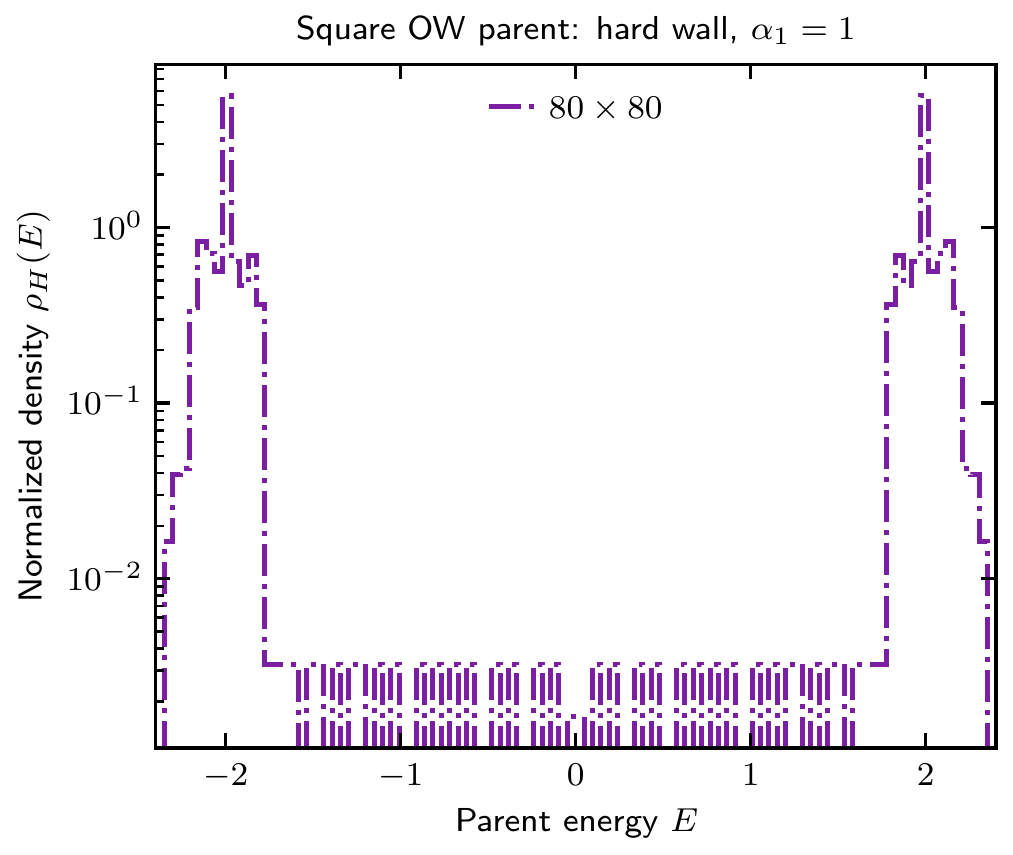

All parent energies included; each size has unit integrated density. Empty bins are gaps on the log axis. One deterministic Hamiltonian per size, with no trajectory averaging.

In [5]:
ENERGY_BIN_COUNT=100
PLOT_SIZES=[80]  # Display selection; all computed spectra remain cached.
import matplotlib as mpl
import matplotlib.pyplot as plt
import subprocess
os.environ["TEXINPUTS"]=str(OUTPUT_DIR/"latex_support")+os.pathsep+os.environ.get("TEXINPUTS","")
mpl.rcParams.update({"font.family":"sans-serif","font.sans-serif":["CMU Sans Serif"],
 "font.size":8,"axes.labelsize":8,"axes.titlesize":8,"xtick.labelsize":8,"ytick.labelsize":8,
 "text.usetex":True,"pdf.fonttype":42,"xtick.direction":"in","ytick.direction":"in"})
STYLES=[("#c62828",":"),("#2e7d32","--"),("#1565c0","-"),("#7b1fa2","-.")]
energy_limit=np.ceil(10*max(np.max(np.abs(energies_by_size[ny])) for ny in PLOT_SIZES))/10
energy_edges=np.linspace(-energy_limit,energy_limit,ENERGY_BIN_COUNT+1)
energy_widths=np.diff(energy_edges)
energy_rows,energy_summaries=[],{}
fig,ax=plt.subplots(figsize=(3.375,2.85))
for ny in PLOT_SIZES:
    color,style=STYLES[SIZES.index(ny)]
    e=energies_by_size[ny]
    counts,_=np.histogram(e,bins=energy_edges)
    density=counts/(e.size*energy_widths)
    area=float(np.sum(density*energy_widths))
    require(int(counts.sum())==e.size and abs(area-1)<1e-14,"Energy normalization failed")
    ax.stairs(np.where(counts>0,density,np.nan),energy_edges,color=color,linestyle=style,
              linewidth=1.2 if ny==80 else .8,label="$"+rf"{ny}\times{ny}"+"$")
    energy_rows.extend([[ny,l,r,int(c),d] for l,r,c,d in zip(energy_edges[:-1],energy_edges[1:],counts,density)])
    energy_summaries[str(ny)]={"states":int(e.size),"area":area,"energy_min":float(e.min()),"energy_max":float(e.max())}
ax.set_yscale("log")
ax.set(xlim=(-energy_limit,energy_limit),xlabel=r"Parent energy $E$",
       ylabel=r"Normalized density $\rho_H(E)$",title=r"Square OW parent: hard wall, $\alpha_1=1$")
ax.tick_params(top=True,right=True)
ax.legend(frameon=False,loc="upper center",ncol=2,handlelength=1.5,columnspacing=.7,handletextpad=.3)
fig.tight_layout(pad=.5)
fig.savefig(OUTPUT_DIR/"equilibrium_hamiltonian_energy_density.pdf")
plt.close(fig)
subprocess.run(["pdftoppm","-r","300","-singlefile","-png",
 str(OUTPUT_DIR/"equilibrium_hamiltonian_energy_density.pdf"),
 str(OUTPUT_DIR/"equilibrium_hamiltonian_energy_density")],check=True)
display(Image(filename=str(OUTPUT_DIR/"equilibrium_hamiltonian_energy_density.png"),width=550))
np.savetxt(OUTPUT_DIR/"hamiltonian_energy_density.csv",energy_rows,delimiter=",",
 header="L,left_edge,right_edge,count,probability_density",comments="",fmt=["%d","%.17g","%.17g","%d","%.17g"])
display(Markdown("All parent energies included; each size has unit integrated density. Empty bins are gaps on the log axis. One deterministic Hamiltonian per size, with no trajectory averaging."))

## Half-system ground-state mixed-mode density
This is the direct equilibrium counterpart of the circuit mixed-mode plot. Exclude modes within the editable endpoint tolerance, then normalize the retained modes separately for each size.

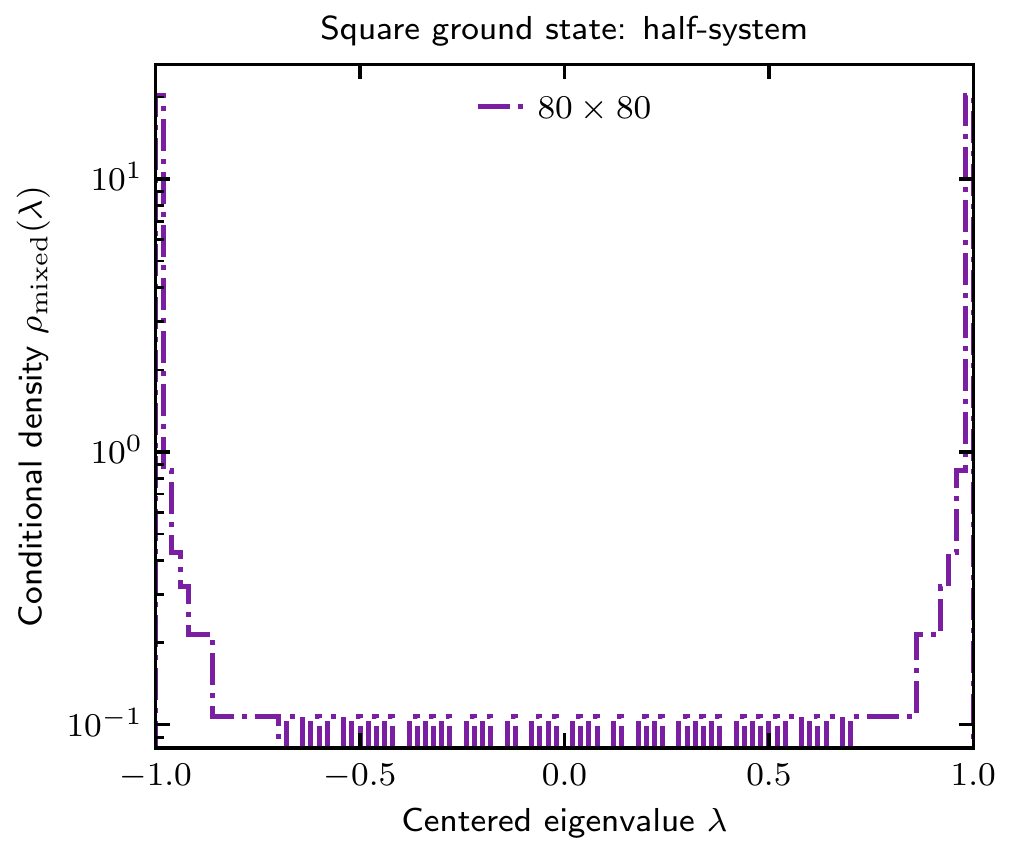

Retain abs(lambda)<1-1e-08, with unit integrated density per size. Each spectrum comes from one equilibrium ground state; gaps between occupied bins reflect its discrete levels.

In [6]:
MIXED_TOL=1e-8
MIXED_BIN_COUNT=100
require(0<MIXED_TOL<1,"Invalid mixed-mode tolerance")
mixed_edges=np.linspace(-1,1,MIXED_BIN_COUNT+1)
mixed_widths=np.diff(mixed_edges)
mixed_rows,mixed_summaries=[],{}
fig,ax=plt.subplots(figsize=(3.375,2.85))
for ny in PLOT_SIZES:
    color,style=STYLES[SIZES.index(ny)]
    raw=spectra_by_size[ny]
    values=raw[np.abs(raw)<1-MIXED_TOL]
    require(values.size>0,"No mixed modes retained")
    counts,_=np.histogram(values,bins=mixed_edges)
    density=counts/(values.size*mixed_widths)
    area=float(np.sum(density*mixed_widths))
    require(counts.sum()==values.size and abs(area-1)<1e-14,"Mixed-mode normalization failed")
    ax.stairs(np.where(counts>0,density,np.nan),mixed_edges,color=color,linestyle=style,
              linewidth=1.2 if ny==80 else .8,label="$"+rf"{ny}\times{ny}"+"$")
    mixed_rows.extend([[ny,l,r,int(c),d] for l,r,c,d in zip(mixed_edges[:-1],mixed_edges[1:],counts,density)])
    mixed_summaries[str(ny)]={"total_modes":int(raw.size),"retained_modes":int(values.size),
                              "retained_fraction":float(values.size/raw.size),"area":area,
                              "minimum_abs_centered_eigenvalue":float(np.min(np.abs(raw)))}
ax.set_yscale("log")
ax.set(xlim=(-1,1),xlabel=r"Centered eigenvalue $\lambda$",
 ylabel=r"Conditional density $\rho_{\mathrm{mixed}}(\lambda)$",
 title="Square ground state: half-system")
ax.tick_params(top=True,right=True)
ax.set_xticks([-1,-.5,0,.5,1])
ax.legend(frameon=False,loc="upper center",ncol=2,handlelength=1.5,columnspacing=.7,handletextpad=.3)
fig.tight_layout(pad=.5)
fig.savefig(OUTPUT_DIR/"equilibrium_half_system_mixed_density.pdf")
plt.close(fig)
subprocess.run(["pdftoppm","-r","300","-singlefile","-png",
 str(OUTPUT_DIR/"equilibrium_half_system_mixed_density.pdf"),
 str(OUTPUT_DIR/"equilibrium_half_system_mixed_density")],check=True)
display(Image(filename=str(OUTPUT_DIR/"equilibrium_half_system_mixed_density.png"),width=550))
np.savetxt(OUTPUT_DIR/"half_system_mixed_density.csv",mixed_rows,delimiter=",",
 header="L,left_edge,right_edge,count,conditional_probability_density",comments="",fmt=["%d","%.17g","%.17g","%d","%.17g"])
display(Markdown(f"Retain abs(lambda)<1-{MIXED_TOL:g}, with unit integrated density per size. Each spectrum comes from one equilibrium ground state; gaps between occupied bins reflect its discrete levels."))

## Diagnostics and provenance

In [7]:
caption=("Two separate normalized spectral densities for the equilibrium OW parent, hard walls at x=L/4,3L/4, "
 "Displayed: Nx=Ny=80. Cached sizes L=20,40,60,80; alpha_1=1, alpha_2=30, nshell=1, trial orbital X, zero twists. "
 "One deterministic parent and half-filled ground state per size. Hamiltonian energy density includes all "
 f"levels with {ENERGY_BIN_COUNT} common bins, no energy rescaling. Ground-state centered covariance is "
 "restricted to all x and y=0..Ny/2-1 with both orbitals; "
 f"mixed-mode density retains abs(lambda)<1-{MIXED_TOL:g} using {MIXED_BIN_COUNT} common bins. "
 "Each density is normalized separately to unit bin-integrated area. Log vertical axes; empty bins are "
 "gaps, no pseudocounts. No uncertainty estimates, fits, circuit evolution, or trajectory averaging. "
 "When the Fermi gap is below 1e-10, the selected pure ground state depends on the unresolved-subspace occupation. Ground-state occupations follow the reference's global stable energy sort across y-momentum blocks.")
(OUTPUT_DIR/"figure_captions.txt").write_text(caption+"\n")
summary={"schema":"equilibrium_flattened_square_spectral_density_analysis_v1",
 "created_utc":datetime.now(timezone.utc).isoformat(),"contract":contract,
 "displayed_sizes":PLOT_SIZES,"energy_bins":ENERGY_BIN_COUNT,"mixed_bins":MIXED_BIN_COUNT,"mixed_tolerance":MIXED_TOL,
 "hamiltonian_density":energy_summaries,"half_system_density":mixed_summaries,
 "numerical_diagnostics":diagnostics_by_size,
 "runtime":{"python":platform.python_version() if "platform" in globals() else sys.version,
            "numpy":np.__version__,"scipy":scipy.__version__,"cpus":selected_cpus},
 "all_checks_passed":True}
summary["outputs"]={p.name:sha256(p) for p in OUTPUT_DIR.iterdir()
                    if p.suffix in [".npz",".csv",".pdf",".png"] or p.name=="figure_captions.txt"}
(OUTPUT_DIR/"analysis_summary.json").write_text(json.dumps(summary,default=native,indent=2,allow_nan=False)+"\n")
print(json.dumps({"energy":energy_summaries,"mixed":mixed_summaries},indent=2))
for ny,d in diagnostics_by_size.items():
    print(ny,"gap",d["half_filling_gap"],"projector error",d["projector_idempotency_max_abs"],
          "reduced trace error",d["restricted_trace_error"])
print("Complete:",OUTPUT_DIR)

{
  "energy": {
    "80": {
      "states": 12800,
      "area": 1.0,
      "energy_min": -2.311040100860378,
      "energy_max": 2.3110401008603763
    }
  },
  "mixed": {
    "80": {
      "total_modes": 6400,
      "retained_modes": 468,
      "retained_fraction": 0.073125,
      "area": 1.0,
      "minimum_abs_centered_eigenvalue": 0.026600653789854597
    }
  }
}
20 gap 1.5022341790844665e-09 projector error 1.6653345369377348e-15 reduced trace error 5.684341886080802e-14
40 gap 2.4989683530861713e-15 projector error 2.4424906541753444e-15 reduced trace error 2.2737367544323206e-13
60 gap 3.3143339277639105e-17 projector error 2.1094237467877974e-15 reduced trace error 0.0
80 gap 1.7711931768907936e-15 projector error 2.6645352591003757e-15 reduced trace error 4.547473508864641e-13
Complete: /home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/06_domain_wall_flattened_ground_state_reference/analysis_outputs/equilibrium_flattened_spect